# Quantum Teleportation

Quantum teleportation is the protocol that lets Alice **transfer the state of a qubit** to Bob using only:

1. one **shared entangled pair** (a Bell state distributed in advance), and
2. **two classical bits** of communication.

The qubit's wavefunction itself is never sent through the network – only those two classical bits.

In this notebook we build the standard 3-qubit teleportation circuit:

| Qubit | Role |
|---|---|
| 0 | Alice's message qubit (the state to be teleported) |
| 1 | Alice's half of the Bell pair |
| 2 | Bob's half of the Bell pair |

> **What changed since the original notebook?** All the Qiskit-1.0 changes we saw in `QX01`: explicit imports, `AerSimulator` from `qiskit_aer`, `transpile` + `run` instead of `execute`.

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

%matplotlib inline

## 1. The setup

Three qubits:

- **Qubit 0** – the state Alice wants to send. We prepare it in `|1⟩` with an `X` gate (any state would work, but `|1⟩` makes the success condition easy to read off the histogram).
- **Qubits 1 & 2** – an **entangled Bell pair** shared between Alice (qubit 1) and Bob (qubit 2). The pair is created with `H` on qubit 1 followed by `CX(1, 2)`.

The `barrier()` calls are purely cosmetic – they break the diagram into clearly-separated stages.

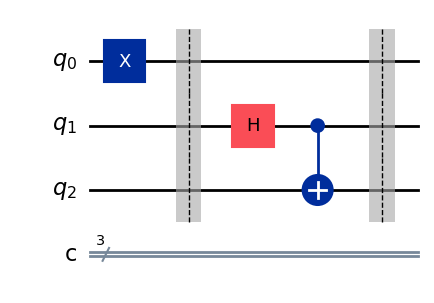

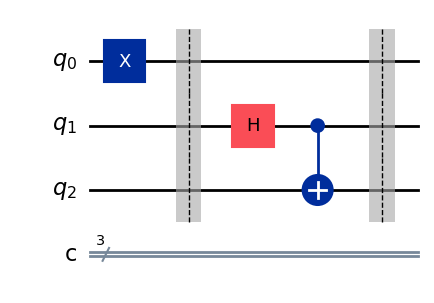

In [2]:
circuit = QuantumCircuit(3,3)

circuit.x(0)

circuit.barrier()

circuit.h(1)
circuit.cx(1,2)

circuit.barrier()

circuit.draw(output='mpl')

## 2. Alice's Bell-state measurement

Alice now applies a `CX` followed by `H` on her two qubits (the "Bell measurement basis change"). This is what entangles her message qubit with the half of the Bell pair she holds, ready to be measured.

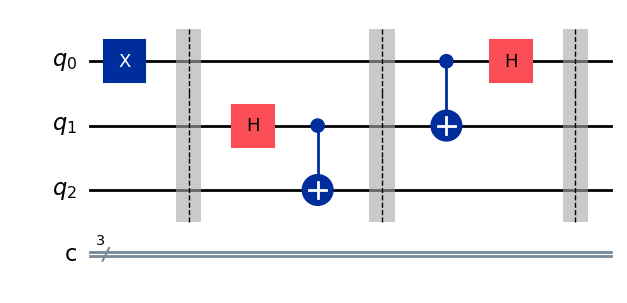

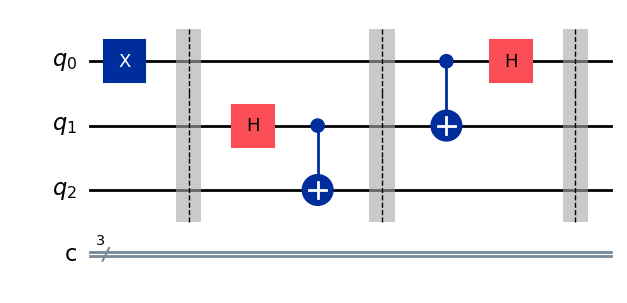

In [3]:
circuit.cx(0,1)
circuit.h(0)

circuit.barrier()
circuit.draw(output='mpl')

## 3. Alice measures her two qubits

Alice measures qubits 0 and 1 in the computational basis. The two resulting **classical bits** are the message she has to send (over a classical channel) to Bob.

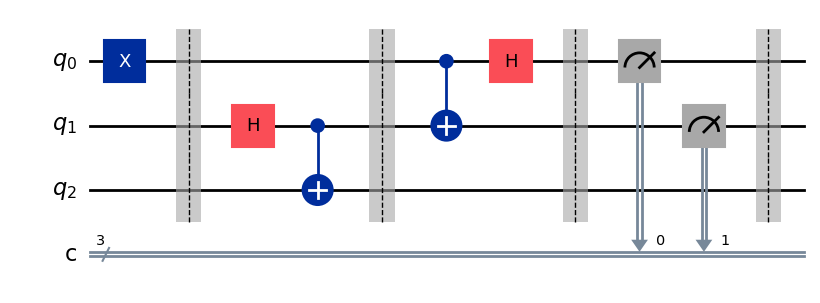

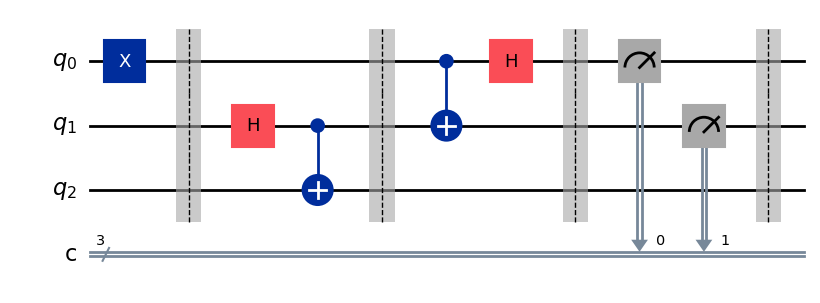

In [4]:
circuit.measure([0,1],[0,1])
circuit.barrier()

circuit.draw(output='mpl')

## 4. Bob applies corrections

Based on the two classical bits, Bob fixes up his qubit by conditionally applying `X` (controlled by the second classical bit) and `Z` (controlled by the first). Here we use the trick of **conditioning on classical bits via further CNOT/CZ gates** so that the whole circuit runs on a single device. Finally we measure qubit 2 to see whether the teleportation worked.

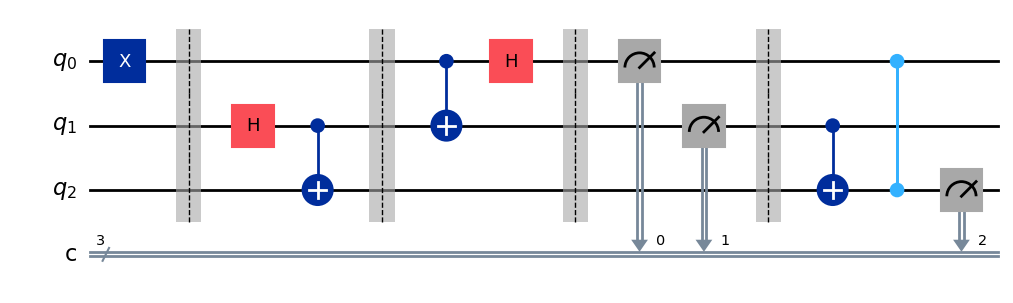

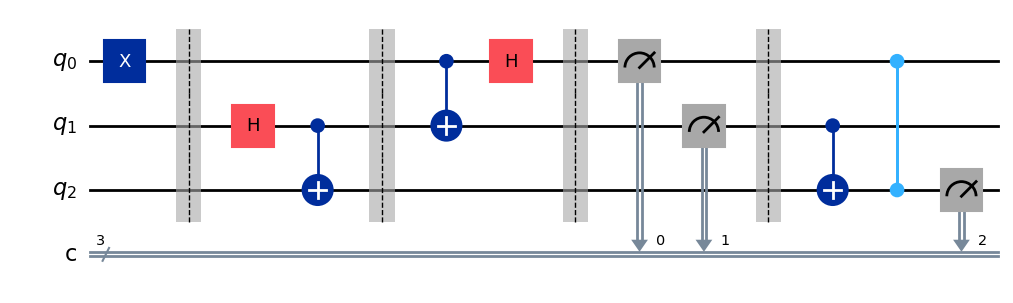

In [5]:
circuit.cx(1,2)
circuit.cz(0,2)

circuit.measure([2],[2])
circuit.draw(output='mpl')

## Running the protocol

We sample 1024 shots on the local `AerSimulator`. The output bit corresponding to qubit 2 should always be `1`, regardless of the random outcomes of the two earlier measurements – proof that the original |1⟩ has been faithfully teleported to qubit 2.

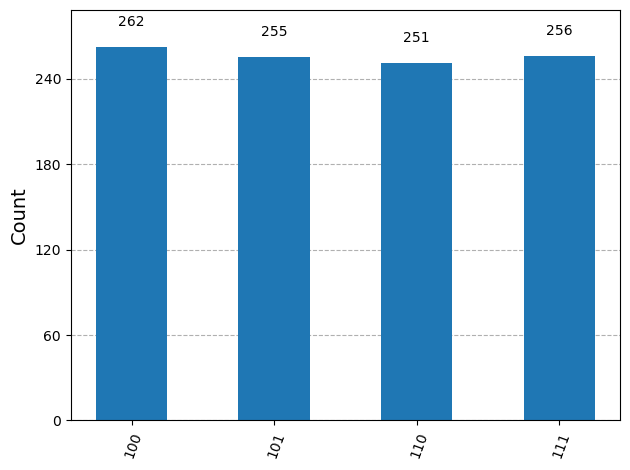

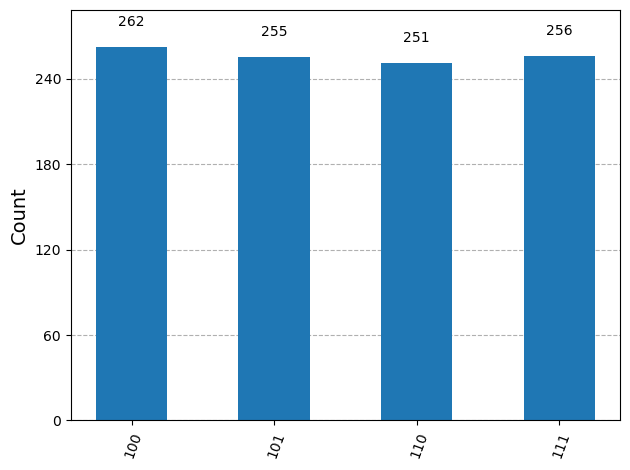

In [6]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
result = simulator.run(compiled, shots=1024).result()
plot_histogram(result.get_counts(circuit))